# 实验七之二：LMCC 条件 GAN 手写数字生成

本 Notebook 对应《GAN》3.1 节的 LMCC 实验：在 MNIST 上训练条件生成对抗网络（Conditional GAN），并按给定标签生成指定数字。

实验与课件保持一致：

- 数据：MNIST 训练集，归一化到 `[-1, 1]`，`batch_size=64`；
- 生成器：100 维噪声与 10 维标签嵌入拼接，经全连接网络生成 `1×28×28` 图像；
- 判别器：图像与 784 维标签嵌入拼接，判断输入图像是否真实；
- 训练：`BCELoss`，Adam 学习率 `0.0002`，`betas=(0.5, 0.999)`，正式训练 10 轮；
- 生成：输入目标标签，保存并展示指定数字（课件示例为数字 7）。

> 默认参数就是课件要求的正式实验参数。设置环境变量 `LAB7_FAST_DEV_RUN=1` 时，仅抽取少量数据、运行少量批次，用来检查完整代码链路；这不是正式实验结果。

## 1. 导入依赖并设置实验参数

LMCC 环境通常已经提供 PyTorch 与 torchvision，不需要安装课件截图中误写的 `transform` 包。固定随机种子便于复现实验；设备优先使用 CUDA，CUDA 不可用时自动使用 CPU。

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid, save_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

FAST_DEV_RUN = os.getenv("LAB7_FAST_DEV_RUN", "0") == "1"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NOISE_DIM = 100
NUM_CLASSES = 10
BATCH_SIZE = 64
NUM_EPOCHS = 1 if FAST_DEV_RUN else 10
MAX_BATCHES = 2 if FAST_DEV_RUN else None
LEARNING_RATE = 0.0002
BETAS = (0.5, 0.999)

print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"device: {DEVICE}")
print(f"FAST_DEV_RUN: {FAST_DEV_RUN}")
print(f"epochs: {NUM_EPOCHS}, max_batches_per_epoch: {MAX_BATCHES or '全部'}")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


PyTorch: 2.2.2
torchvision: 0.17.2
device: cpu
FAST_DEV_RUN: False
epochs: 10, max_batches_per_epoch: 全部


## 2. 加载并检查 MNIST 数据

`ToTensor` 先把像素缩放到 `[0, 1]`，再用均值和标准差 `0.5` 归一化到 `[-1, 1]`，与生成器最后一层的 `Tanh` 输出范围一致。

程序优先使用当前目录的 `data/MNIST/raw`；为了便于在本仓库本地运行，也会检查 `../lab1-2/data` 的已有缓存。只有找不到缓存时才尝试下载。

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

REQUIRED_RAW_FILES = (
    "train-images-idx3-ubyte",
    "train-labels-idx1-ubyte",
    "t10k-images-idx3-ubyte",
    "t10k-labels-idx1-ubyte",
)


def has_mnist_cache(root):
    raw_dir = Path(root) / "MNIST" / "raw"
    return all((raw_dir / name).exists() for name in REQUIRED_RAW_FILES)


data_candidates = [Path("data"), Path("../lab1-2/data")]
cached_root = next((path for path in data_candidates if has_mnist_cache(path)), None)
DATA_ROOT = cached_root if cached_root is not None else Path("data")

try:
    dataset = torchvision.datasets.MNIST(
        root=DATA_ROOT,
        train=True,
        download=cached_root is None,
        transform=transform,
    )
except Exception as exc:
    raise RuntimeError(
        "MNIST 加载失败。请在 LMCC 保持网络可用后重试，或把 MNIST 文件放入 "
        f"{(Path('data') / 'MNIST' / 'raw').resolve()}。"
    ) from exc

full_dataset_size = len(dataset)
if FAST_DEV_RUN:
    dataset = Subset(dataset, range(min(256, full_dataset_size)))

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

sample_images, sample_labels = next(iter(dataloader))
assert sample_images.shape[1:] == (1, 28, 28)
assert sample_images.min() >= -1.0 and sample_images.max() <= 1.0

print(f"MNIST 根目录: {DATA_ROOT.resolve()}")
print(f"完整训练集: {full_dataset_size} 张；本次使用: {len(dataset)} 张")
print(f"一个批次图像形状: {tuple(sample_images.shape)}")

preview = make_grid((sample_images[:16] + 1) / 2, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(preview.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("MNIST training samples")
plt.axis("off")
plt.show()

MNIST 根目录: /Users/bob.li/Code/DL-ZJU/lab1-2/data
完整训练集: 60000 张；本次使用: 60000 张
一个批次图像形状: (64, 1, 28, 28)


<Figure size 600x600 with 1 Axes>

## 3. 创建条件生成器与条件判别器

生成器学习 $G(z, y)$：随机噪声 $z$ 决定笔画风格，数字标签 $y$ 决定要生成哪一类数字。判别器学习 $D(x, y)$：同时观察图像与标签，判断“这张图是否是真实的、且是否与标签匹配”。

In [3]:
class ConditionalGenerator(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, noise_dim=NOISE_DIM):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 10)
        self.net = nn.Sequential(
            nn.Linear(noise_dim + 10, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28 * 28),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        label_features = self.label_emb(labels)
        model_input = torch.cat((z, label_features), dim=1)
        return self.net(model_input).view(-1, 1, 28, 28)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 28 * 28)
        self.net = nn.Sequential(
            nn.Linear(28 * 28 + 28 * 28, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, images, labels):
        image_features = images.view(images.size(0), -1)
        label_features = self.label_emb(labels).view(labels.size(0), -1)
        model_input = torch.cat((image_features, label_features), dim=1)
        return self.net(model_input)


generator = ConditionalGenerator().to(DEVICE)
discriminator = ConditionalDiscriminator().to(DEVICE)

test_batch_size = 4
test_noise = torch.randn(test_batch_size, NOISE_DIM, device=DEVICE)
test_labels = torch.arange(test_batch_size, device=DEVICE)
test_fake_images = generator(test_noise, test_labels)
test_scores = discriminator(test_fake_images, test_labels)

assert test_fake_images.shape == (test_batch_size, 1, 28, 28)
assert test_scores.shape == (test_batch_size, 1)
print("生成器输出形状:", tuple(test_fake_images.shape))
print("判别器输出形状:", tuple(test_scores.shape))
print(f"生成器参数量: {sum(p.numel() for p in generator.parameters()):,}")
print(f"判别器参数量: {sum(p.numel() for p in discriminator.parameters()):,}")

生成器输出形状: (4, 1, 28, 28)
判别器输出形状: (4, 1)
生成器参数量: 1,489,012
判别器参数量: 2,270,881


## 4. 初始化损失函数、优化器和固定观察样本

判别器把真实样本目标设为 1、生成样本目标设为 0；生成器则希望判别器把生成样本判断为 1。固定噪声与固定标签用于比较不同训练轮次的生成效果。

In [4]:
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=BETAS)

SAVE_DIR = Path("images")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

fixed_labels = torch.arange(NUM_CLASSES, device=DEVICE).repeat_interleave(5)
fixed_noise = torch.randn(len(fixed_labels), NOISE_DIM, device=DEVICE)

print("损失函数:", criterion)
print("优化器: Adam")
print("生成样例目录:", SAVE_DIR.resolve())

损失函数: BCELoss()
优化器: Adam
生成样例目录: /Users/bob.li/Code/DL-ZJU/lab7-2/images


## 5. 训练条件 GAN

每个批次交替更新生成器与判别器：

1. 生成器产生带标签的假图像，并尽量让判别器把它判断为真实；
2. 判别器同时学习识别真实图像和生成器产生的假图像；
3. 每轮记录平均损失，并保存固定标签对应的生成结果。

GAN 的损失会相互博弈，数值不一定单调下降，因此还应直接观察生成图像的清晰度与类别一致性。

In [5]:
loss_history_G = []
loss_history_D = []

for epoch in range(1, NUM_EPOCHS + 1):
    generator.train()
    discriminator.train()
    running_G = 0.0
    running_D = 0.0
    processed_batches = 0

    for batch_index, (real_images, real_labels) in enumerate(dataloader):
        if MAX_BATCHES is not None and batch_index >= MAX_BATCHES:
            break

        real_images = real_images.to(DEVICE)
        real_labels = real_labels.to(DEVICE)
        current_batch_size = real_images.size(0)
        valid = torch.ones(current_batch_size, 1, device=DEVICE)
        fake = torch.zeros(current_batch_size, 1, device=DEVICE)

        # 训练生成器：希望生成图像被判别器判为真实。
        optimizer_G.zero_grad()
        noise = torch.randn(current_batch_size, NOISE_DIM, device=DEVICE)
        generated_labels = torch.randint(
            0, NUM_CLASSES, (current_batch_size,), device=DEVICE
        )
        generated_images = generator(noise, generated_labels)
        g_loss = criterion(
            discriminator(generated_images, generated_labels), valid
        )
        g_loss.backward()
        optimizer_G.step()

        # 训练判别器：真实图像判为 1，生成图像判为 0。
        optimizer_D.zero_grad()
        real_loss = criterion(discriminator(real_images, real_labels), valid)
        fake_loss = criterion(
            discriminator(generated_images.detach(), generated_labels), fake
        )
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        running_G += g_loss.item()
        running_D += d_loss.item()
        processed_batches += 1

    if processed_batches == 0:
        raise RuntimeError("训练没有处理任何批次，请检查数据集和 DataLoader。")

    epoch_g_loss = running_G / processed_batches
    epoch_d_loss = running_D / processed_batches
    loss_history_G.append(epoch_g_loss)
    loss_history_D.append(epoch_d_loss)

    generator.eval()
    with torch.no_grad():
        fixed_samples = generator(fixed_noise, fixed_labels)
    save_image(
        fixed_samples.cpu(),
        SAVE_DIR / f"epoch_{epoch:02d}.png",
        nrow=5,
        normalize=True,
        value_range=(-1, 1),
    )

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | "
        f"D Loss: {epoch_d_loss:.4f} | G Loss: {epoch_g_loss:.4f} | "
        f"batches: {processed_batches}"
    )

if FAST_DEV_RUN:
    print("\n当前输出来自 FAST_DEV_RUN，只验证代码链路，不代表正式训练质量。")

Epoch [01/10] | D Loss: 0.3423 | G Loss: 1.9957 | batches: 938
Epoch [02/10] | D Loss: 0.3021 | G Loss: 2.1338 | batches: 938
Epoch [03/10] | D Loss: 0.3375 | G Loss: 1.9634 | batches: 938
Epoch [04/10] | D Loss: 0.3964 | G Loss: 1.6923 | batches: 938
Epoch [05/10] | D Loss: 0.4154 | G Loss: 1.6230 | batches: 938
Epoch [06/10] | D Loss: 0.4464 | G Loss: 1.5198 | batches: 938
Epoch [07/10] | D Loss: 0.4777 | G Loss: 1.3927 | batches: 938
Epoch [08/10] | D Loss: 0.5033 | G Loss: 1.2950 | batches: 938
Epoch [09/10] | D Loss: 0.5202 | G Loss: 1.2392 | batches: 938
Epoch [10/10] | D Loss: 0.5365 | G Loss: 1.1833 | batches: 938


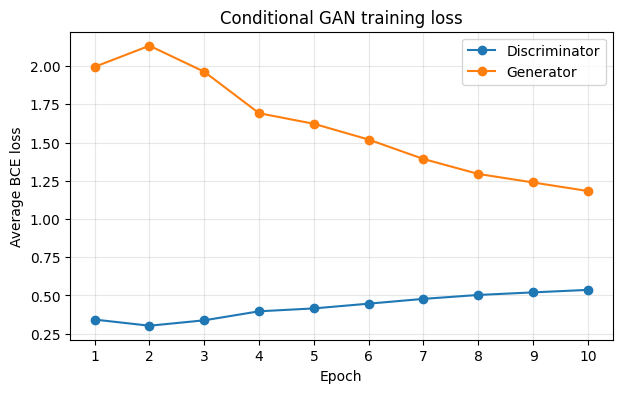

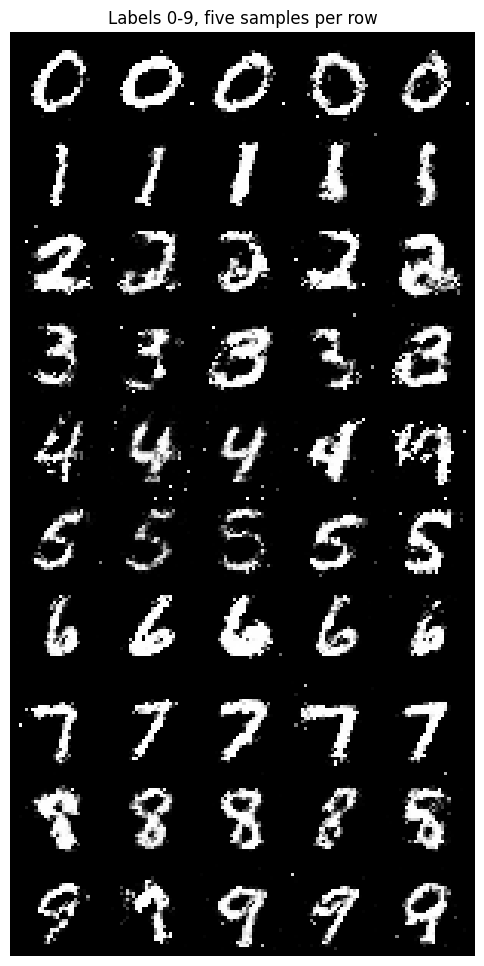

In [6]:
epochs = range(1, len(loss_history_G) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs, loss_history_D, marker="o", label="Discriminator")
plt.plot(epochs, loss_history_G, marker="o", label="Generator")
plt.xlabel("Epoch")
plt.ylabel("Average BCE loss")
plt.title("Conditional GAN training loss")
plt.xticks(list(epochs))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

generator.eval()
with torch.no_grad():
    final_samples = generator(fixed_noise, fixed_labels).cpu()

final_grid = make_grid(
    (final_samples + 1) / 2,
    nrow=5,
    padding=2,
)
plt.figure(figsize=(6, 12))
plt.imshow(final_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title("Labels 0-9, five samples per row")
plt.axis("off")
plt.show()

## 6. 生成指定数字

下面实现课件的最后一步。修改 `DIGIT_TO_GENERATE` 为 `0` 到 `9` 中的任意整数，即可生成对应数字。一次生成 16 张，便于观察同一类别下不同噪声带来的书写风格变化。

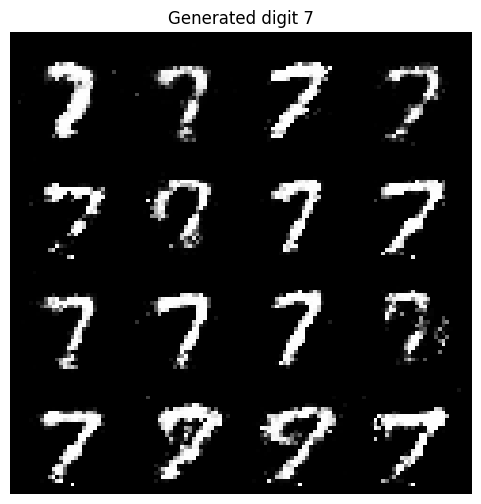

已保存: /Users/bob.li/Code/DL-ZJU/lab7-2/digit_7.png
生成张量形状: (16, 1, 28, 28)


In [7]:
def generate_specific_digit(generator, digit, count=16, device=DEVICE):
    if not 0 <= digit < NUM_CLASSES:
        raise ValueError(f"digit 必须在 0 到 {NUM_CLASSES - 1} 之间")

    generator.eval()
    with torch.no_grad():
        noise = torch.randn(count, NOISE_DIM, device=device)
        labels = torch.full((count,), digit, dtype=torch.long, device=device)
        generated_images = generator(noise, labels)
    return generated_images.cpu()


DIGIT_TO_GENERATE = 7
digit_images = generate_specific_digit(generator, DIGIT_TO_GENERATE)
digit_path = Path(f"digit_{DIGIT_TO_GENERATE}.png")
save_image(
    digit_images,
    digit_path,
    nrow=4,
    normalize=True,
    value_range=(-1, 1),
)

digit_grid = make_grid((digit_images + 1) / 2, nrow=4)
plt.figure(figsize=(6, 6))
plt.imshow(digit_grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.title(f"Generated digit {DIGIT_TO_GENERATE}")
plt.axis("off")
plt.show()

print(f"已保存: {digit_path.resolve()}")
print("生成张量形状:", tuple(digit_images.shape))

## 7. 实验观察与结论

正式运行 10 轮后，请结合上面的损失曲线和生成样例记录：

- 生成图像是否逐渐从噪声形成可辨认的数字；
- 不同标签生成的图像是否具有正确类别；
- 同一标签下的不同样本是否保持一定多样性；
- 判别器与生成器损失是否处于动态博弈，而不是仅依据某一方损失是否单调下降来判断训练质量。

最终结论应以 LMCC 上关闭快速模式、完整运行 10 轮所得的实际输出为准。